In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Carrega os CSVs
df_attack = pd.read_csv("../data/raw/attack_samples_5sec.csv")
df_benign = pd.read_csv("../data/raw/benign_samples_5sec.csv")

# Adiciona labels
df_attack["label"] = 1
df_benign["label"] = 0

# Junta os dois csv
df = pd.concat([df_attack, df_benign], ignore_index=True)

# Separa features numericas e label
df_numeric = df.select_dtypes(include=[np.number])
X = df_numeric.drop(columns=["label"])
y = df_numeric["label"]

print(f"Features disponiveis: {X.shape[1]}")
print(f"Total de amostras: {X.shape[0]}")
print(f"Distribuicao de classes:\n{y.value_counts()}")

Features disponiveis: 71
Total de amostras: 45055
Distribuicao de classes:
label
0    27360
1    17695
Name: count, dtype: int64


=== TOP 20 FEATURES ===
                              feature  importance
36          network_packets_all_count    0.133202
37          network_packets_dst_count    0.077475
45            network_ports_src_count    0.065060
43            network_ports_all_count    0.064197
59             network_time-delta_avg    0.054975
34            network_packet-size_min    0.052615
44            network_ports_dst_count    0.051797
38          network_packets_src_count    0.042810
52        network_tcp-flags-rst_count    0.040466
53        network_tcp-flags-syn_count    0.033781
49        network_tcp-flags-ack_count    0.026097
60             network_time-delta_max    0.024374
70  network_window-size_std_deviation    0.020835
61             network_time-delta_min    0.019779
29                    network_mss_max    0.016104
62   network_time-delta_std_deviation    0.015616
63                    network_ttl_avg    0.013064
33            network_packet-size_max    0.011756
13           network_inter

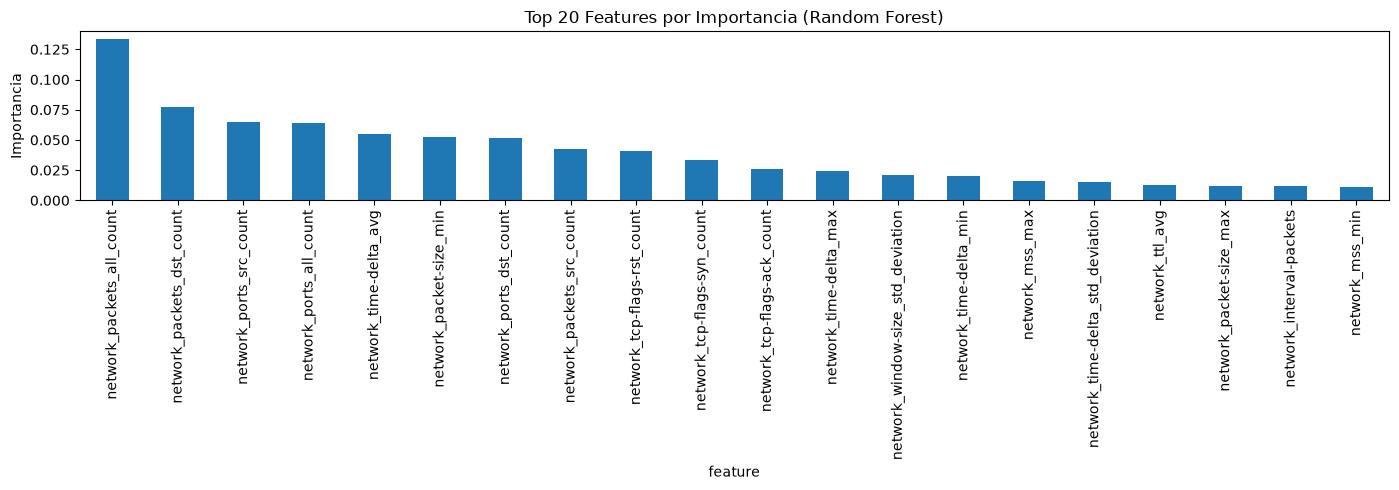


Features selecionadas: ['network_packets_all_count', 'network_packets_dst_count', 'network_ports_src_count', 'network_ports_all_count', 'network_time-delta_avg', 'network_packet-size_min', 'network_ports_dst_count', 'network_packets_src_count', 'network_tcp-flags-rst_count', 'network_tcp-flags-syn_count', 'network_tcp-flags-ack_count', 'network_time-delta_max', 'network_window-size_std_deviation', 'network_time-delta_min', 'network_mss_max', 'network_time-delta_std_deviation', 'network_ttl_avg', 'network_packet-size_max', 'network_interval-packets', 'network_mss_min']


In [2]:
import os
import matplotlib.pyplot as plt

# Cria a pasta docs se nao existir
os.makedirs("../docs", exist_ok=True)

# Treina Random Forest para medir importancia das features
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Cria tabela com importancia de cada feature
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("=== TOP 20 FEATURES ===")
print(importances.head(20).to_string())

# Salva grafico
importances.head(20).plot(kind="bar", x="feature", y="importance", figsize=(14,5), legend=False)
plt.title("Top 20 Features por Importancia (Random Forest)")
plt.ylabel("Importancia")
plt.tight_layout()
plt.savefig("../docs/grafico_feature_importance.png", dpi=150)
plt.show()

# Seleciona apenas as 20 melhores
top20_features = importances.head(20)["feature"].tolist()
print(f"\nFeatures selecionadas: {top20_features}")

In [3]:
# Divisão estratificada: 70% treino, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X[top20_features], y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Divide os 30% em 15% validacao e 15% teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validacao: {X_val.shape[0]} amostras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)")

Treino:    31538 amostras (70.0%)
Validacao: 6758 amostras (15.0%)
Teste:     6759 amostras (15.0%)


In [4]:
# Cria o scaler e treina APENAS no conjunto de treino
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Aplica a mesma escala em validação e teste (sem re-treinar)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Antes da normalização (treino):")
print(f"  Mínimo: {X_train.values.min():.2f} | Máximo: {X_train.values.max():.2f}")
print("Após normalização (treino):")
print(f"  Mínimo: {X_train_scaled.min():.2f} | Máximo: {X_train_scaled.max():.2f}")

Antes da normalização (treino):
  Mínimo: -0.00 | Máximo: 744221.00
Após normalização (treino):
  Mínimo: 0.00 | Máximo: 1.00


In [5]:
# SMOTE aplicado APENAS no treino
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Antes do SMOTE (treino):")
print(pd.Series(y_train).value_counts())

print("\nApos SMOTE (treino):")
print(pd.Series(y_train_balanced).value_counts())

Antes do SMOTE (treino):
label
0    19152
1    12386
Name: count, dtype: int64

Apos SMOTE (treino):
label
1    19152
0    19152
Name: count, dtype: int64


In [6]:
import os

# LSTM espera entrada 3D: [amostras, timesteps, features]
# timesteps=1 porque cada linha já representa uma janela de 5 segundos
X_train_lstm = X_train_balanced.reshape(X_train_balanced.shape[0], 1, X_train_balanced.shape[1])
X_val_lstm   = X_val_scaled.reshape(X_val_scaled.shape[0], 1, X_val_scaled.shape[1])
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

print(f"Shape treino LSTM:    {X_train_lstm.shape}")
print(f"Shape validacao LSTM: {X_val_lstm.shape}")
print(f"Shape teste LSTM:     {X_test_lstm.shape}")

# Salva os arrays processados
os.makedirs("../data/processed/v1", exist_ok=True)

np.save("../data/processed/v1/X_train.npy", X_train_lstm)
np.save("../data/processed/v1/X_val.npy",   X_val_lstm)
np.save("../data/processed/v1/X_test.npy",  X_test_lstm)
np.save("../data/processed/v1/y_train.npy", y_train_balanced)
np.save("../data/processed/v1/y_val.npy",   y_val.values)
np.save("../data/processed/v1/y_test.npy",  y_test.values)

# Salva a lista de features selecionadas
import json
with open("../data/processed/v1/features_selecionadas.json", "w") as f:
    json.dump(top20_features, f)

print("\nArquivos salvos em data/processed/v1/")

Shape treino LSTM:    (38304, 1, 20)
Shape validacao LSTM: (6758, 1, 20)
Shape teste LSTM:     (6759, 1, 20)

Arquivos salvos em data/processed/v1/
